# Fun experiment · Physics-residual LSTM vs EnergyPlus

**Playground only — not a ship model.**

Train a small PyTorch **physics-residual LSTM** on IdealLoads DSM farm days:

```text
ŷ_kw = (a + b·HDD65) + LSTM_residual(weather, calendar, …)
```

Then plot held-out day vs EnergyPlus `facility_kw` / `site_electric_proxy`.

| Label | Value |
|---|---|
| Physics family | IdealLoads + fixed COP (`STRUCTURAL_LOAD_DIAGNOSTIC`) |
| Honesty | `FUN_EXPERIMENT` / `NON_PROMOTABLE` |
| Not | W2A plant truth · BACnet · grey-box field ID |

Needs site farm parquet:  
`$LAKESIDE_SITE_ROOT/eplus/dsm_farm_paired/heating_dsm_eplus_paired_15min_v1.parquet`

In [19]:
%matplotlib inline
from datetime import datetime
print("KERNEL ALIVE", datetime.now().isoformat(timespec="seconds"), flush=True)

import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path[:0] = [str(ROOT), str(ROOT / "ml"), str(ROOT / "scripts")]

from notebook_plots import apply_notebook_theme, save_fig
from phys_lstm_models import PhysicsResidualLSTM, hdd65

apply_notebook_theme()
torch.manual_seed(0)
np.random.seed(0)

SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))
FARM = SITE / "eplus" / "dsm_farm_paired" / "heating_dsm_eplus_paired_15min_v1.parquet"
FIG = ROOT / "reports" / "figures" / "phys_lstm_fun"
FIG.mkdir(parents=True, exist_ok=True)

if not FARM.is_file():
    raise FileNotFoundError(f"missing E+ farm parquet: {FARM}")

print("torch", torch.__version__)
print("FARM", FARM)
print("SETUP COMPLETE", flush=True)

KERNEL ALIVE 2026-08-10T13:06:46
torch 2.13.0+cpu
FARM C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\dsm_farm_paired\heating_dsm_eplus_paired_15min_v1.parquet
SETUP COMPLETE


## 1 · Load IdealLoads baseline days from the E+ farm

Use `strategy_id == baseline` only so we are learning the E+ day shape, not DSM deltas.

In [20]:
raw = pd.read_parquet(FARM)
kw_col = "facility_kw" if "facility_kw" in raw.columns else "site_electric_proxy_kw"
need = ["day", "strategy_id", "oat_f", kw_col, "zone_temp_1F_A_f"]
for c in need:
    if c not in raw.columns:
        raise SystemExit(f"missing column {c}")

base = raw[raw["strategy_id"].astype(str) == "baseline"].copy()
base = base.dropna(subset=["oat_f", kw_col, "zone_temp_1F_A_f"])
base["hdd"] = hdd65(base["oat_f"].to_numpy(dtype=float))

# complete 96-step days only
counts = base.groupby("day").size()
ok_days = counts[counts == 96].index.astype(str).tolist()
base = base[base["day"].astype(str).isin(ok_days)].sort_values(["day", "timestamp_utc"] if "timestamp_utc" in base.columns else ["day"])

display(Markdown(
    f"Loaded **{len(ok_days)}** complete baseline days · target=`{kw_col}` · "
    f"honesty on rows: `{base['honesty'].iloc[0] if 'honesty' in base.columns else 'n/a'}`"
))
print("days sample", ok_days[:5], "…", ok_days[-3:])

Loaded **6** complete baseline days · target=`facility_kw` · honesty on rows: `HYBRID_SCREENING`

days sample ['2025-10-06', '2025-10-09', '2026-01-05', '2026-01-07', '2026-01-09'] … ['2026-01-07', '2026-01-09', '2026-01-11']


## 2 · Build sequences + fit a linear HDD physics prior

Physics prior (closed form): `kw_phys = a + b·HDD`.  
LSTM learns the **residual** `kw − kw_phys` (and a zone residual).

In [21]:
def day_matrix(df_day: pd.DataFrame):
    oat = df_day["oat_f"].to_numpy(dtype=np.float32)
    hdd = df_day["hdd"].to_numpy(dtype=np.float32)
    kw = df_day[kw_col].to_numpy(dtype=np.float32)
    zone = df_day["zone_temp_1F_A_f"].to_numpy(dtype=np.float32)
    t = np.arange(96, dtype=np.float32)
    sin_t = np.sin(2 * np.pi * t / 96.0).astype(np.float32)
    cos_t = np.cos(2 * np.pi * t / 96.0).astype(np.float32)
    occ = df_day["occupied"].to_numpy(dtype=np.float32) if "occupied" in df_day.columns else np.zeros(96, np.float32)
    # features: oat, hdd, zone_lag, kw_lag, sin, cos, occ, ones
    zone_lag = np.roll(zone, 1); zone_lag[0] = zone[0]
    kw_lag = np.roll(kw, 1); kw_lag[0] = kw[0]
    X = np.column_stack([oat, hdd, zone_lag, kw_lag, sin_t, cos_t, occ, np.ones(96, np.float32)])
    return X, kw, zone, hdd

Xs, Kws, Zones, Hdds, days = [], [], [], [], []
for d, g in base.groupby("day", sort=True):
    g = g.reset_index(drop=True)
    if len(g) != 96:
        continue
    X, kw, zone, hdd = day_matrix(g)
    Xs.append(X); Kws.append(kw); Zones.append(zone); Hdds.append(hdd); days.append(str(d))

Xs = np.stack(Xs)      # (N, 96, 8)
Kws = np.stack(Kws)
Zones = np.stack(Zones)
Hdds = np.stack(Hdds)
print("tensor days", Xs.shape)

# hold out last 2 days for plot / test
n_test = min(2, max(1, len(days) // 5))
n_train = len(days) - n_test
assert n_train >= 2, "need at least 2 train days"

# physics prior on train only
hdd_tr = Hdds[:n_train].ravel()
kw_tr = Kws[:n_train].ravel()
A = np.column_stack([np.ones_like(hdd_tr), hdd_tr])
coef, *_ = np.linalg.lstsq(A, kw_tr, rcond=None)
a_phys, b_phys = float(coef[0]), float(coef[1])
print(f"physics prior: kw ≈ {a_phys:.2f} + {b_phys:.3f}·HDD65")

def phys_kw(hdd):
    return a_phys + b_phys * hdd

Y_res = np.stack([
    np.column_stack([Kws[i] - phys_kw(Hdds[i]), Zones[i] - Zones[i].mean()])
    for i in range(len(days))
]).astype(np.float32)  # (N, 96, 2)

X_tr = torch.tensor(Xs[:n_train])
Y_tr = torch.tensor(Y_res[:n_train])
X_te = torch.tensor(Xs[n_train:])
Y_te = torch.tensor(Y_res[n_train:])
print("train days", days[:n_train])
print("test  days", days[n_train:])

tensor days (6, 96, 8)
physics prior: kw ≈ 44.87 + 1.656·HDD65
train days ['2025-10-06', '2025-10-09', '2026-01-05', '2026-01-07', '2026-01-09']
test  days ['2026-01-11']


## 3 · Train PhysicsResidualLSTM (tiny, CPU)

epoch 000  loss=78.1040


epoch 020  loss=76.2740
epoch 040  loss=74.0344
epoch 060  loss=72.0036
epoch 080  loss=70.0227
epoch 100  loss=68.0593
epoch 120  loss=66.1904
epoch 140  loss=64.2887
epoch 160  loss=62.4151
epoch 180  loss=60.4643
epoch 200  loss=58.5537
epoch 220  loss=56.7523
epoch 240  loss=55.1661
epoch 260  loss=53.4050
epoch 280  loss=51.7393
epoch 300  loss=50.1319
epoch 320  loss=48.5750
epoch 340  loss=47.5021
epoch 360  loss=46.2593
epoch 380  loss=44.8979
epoch 400  loss=43.1935
epoch 420  loss=41.7708
epoch 440  loss=40.3942
epoch 460  loss=39.1827
epoch 480  loss=38.0361
epoch 500  loss=36.9195
epoch 520  loss=35.8138
epoch 540  loss=34.7033
epoch 560  loss=33.0605
epoch 580  loss=31.8392
epoch 600  loss=30.3919
epoch 620  loss=29.1742
epoch 640  loss=28.0329
epoch 660  loss=27.0615
epoch 680  loss=28.4088
epoch 700  loss=26.8753
epoch 720  loss=25.8634
epoch 740  loss=24.9233
epoch 760  loss=23.9915
epoch 780  loss=23.1852
epoch 800  loss=22.4283
epoch 820  loss=21.7075
epoch 840  loss=

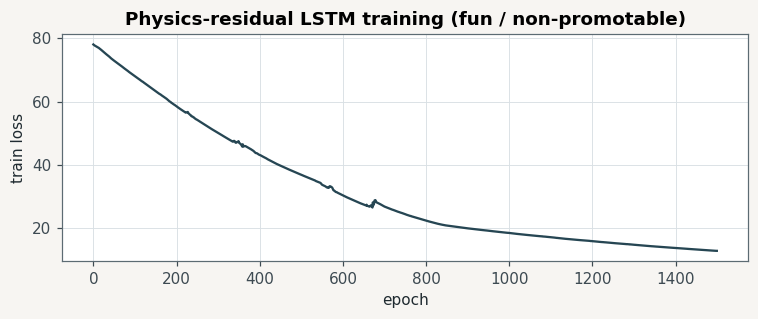

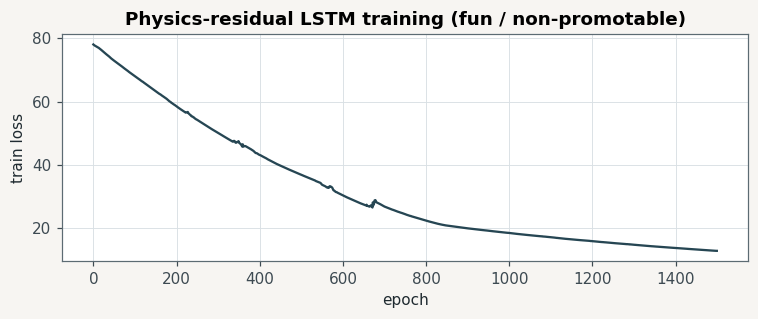

In [22]:
model = PhysicsResidualLSTM(n_in=8, hidden=48, n_out=2)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []
EPOCHS = 1500

model.train()
for ep in range(EPOCHS):
    opt.zero_grad()
    pred = model(X_tr)
    # weight kW residual higher than zone residual
    loss = nn.functional.smooth_l1_loss(pred[..., 0], Y_tr[..., 0]) + 0.25 * nn.functional.smooth_l1_loss(
        pred[..., 1], Y_tr[..., 1]
    )
    loss.backward()
    opt.step()
    losses.append(float(loss.detach()))
    if ep % 20 == 0 or ep == EPOCHS - 1:
        print(f"epoch {ep:03d}  loss={losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses, color="#264653")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss")
ax.set_title("Physics-residual LSTM training (fun / non-promotable)")
fig.tight_layout()
save_fig(FIG / "phys_lstm_train_loss.png", fig)
plt.show()

## 4 · Plot held-out day: E+ vs physics-only vs physics+LSTM

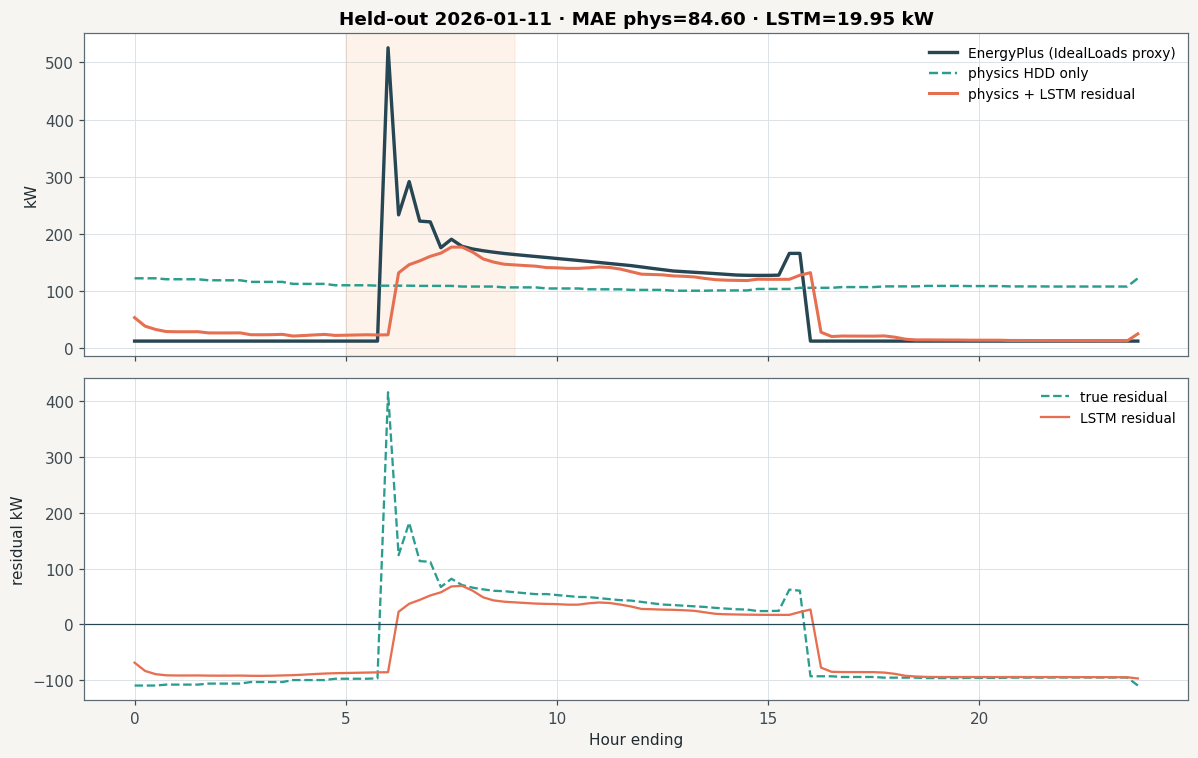

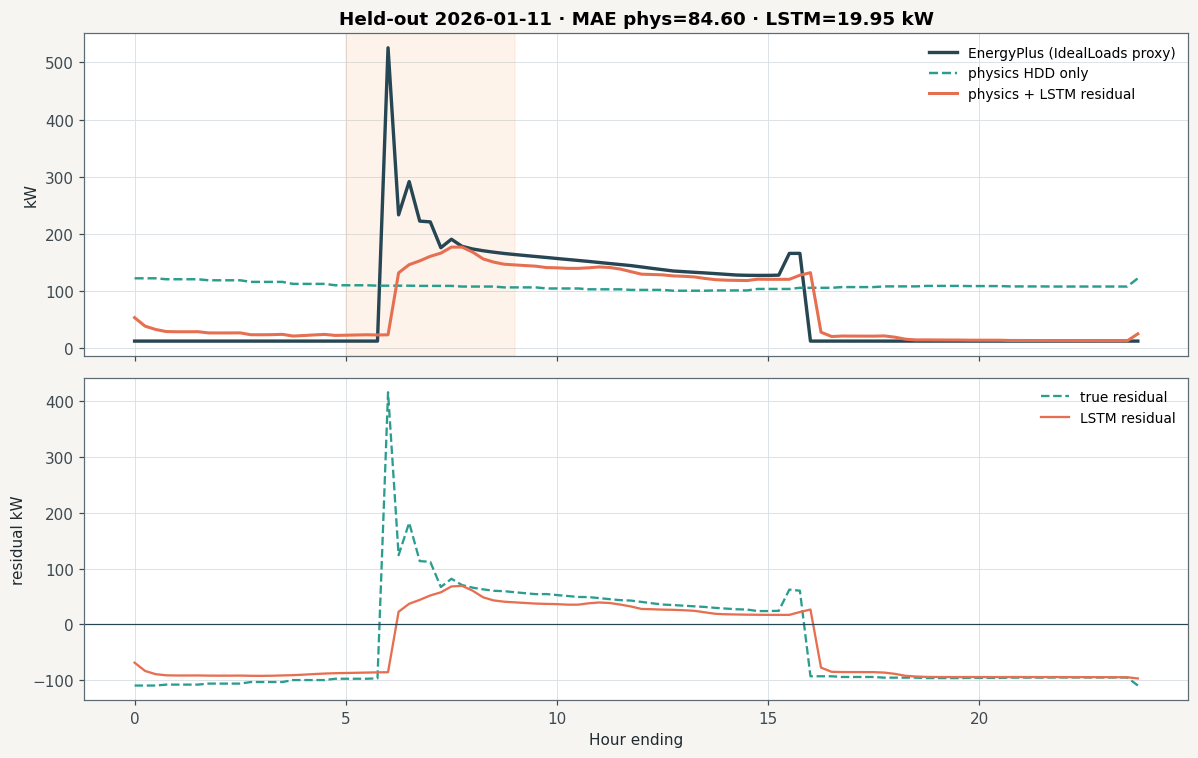

,day,mae_physics_only,mae_phys_plus_lstm
0,2026-01-11,84.601997,19.948183


**Read:** if `mae_phys_plus_lstm` ≪ `mae_physics_only`, the LSTM is picking up IdealLoads schedule/envelope structure beyond HDD. Still **not** W2A plant truth and **not** promotable.

In [23]:
model.eval()
with torch.no_grad():
    pred_te = model(X_te).numpy()

hours = np.arange(96) * 0.25
rows = []

for j, day in enumerate(days[n_train:]):
    hdd = Hdds[n_train + j]
    kw_true = Kws[n_train + j]
    kw_phys = phys_kw(hdd)
    kw_hat = kw_phys + pred_te[j, :, 0]
    mae_phys = float(np.mean(np.abs(kw_true - kw_phys)))
    mae_lstm = float(np.mean(np.abs(kw_true - kw_hat)))
    rows.append({"day": day, "mae_physics_only": mae_phys, "mae_phys_plus_lstm": mae_lstm})

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    ax = axes[0]
    ax.plot(hours, kw_true, color="#264653", lw=2.2, label="EnergyPlus (IdealLoads proxy)")
    ax.plot(hours, kw_phys, color="#2a9d8f", ls="--", lw=1.6, label="physics HDD only")
    ax.plot(hours, kw_hat, color="#e76f51", lw=2.0, label="physics + LSTM residual")
    ax.axvspan(5, 9, color="#f4a261", alpha=0.12)
    ax.set_ylabel("kW")
    ax.set_title(f"Held-out {day} · MAE phys={mae_phys:.2f} · LSTM={mae_lstm:.2f} kW")
    ax.legend(frameon=False, fontsize=9)

    ax = axes[1]
    ax.plot(hours, kw_true - kw_phys, color="#2a9d8f", ls="--", label="true residual")
    ax.plot(hours, pred_te[j, :, 0], color="#e76f51", label="LSTM residual")
    ax.axhline(0, color="#264653", lw=0.8)
    ax.set_xlabel("Hour ending")
    ax.set_ylabel("residual kW")
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    save_fig(FIG / f"phys_lstm_vs_eplus_{day}.png", fig)
    plt.show()

score = pd.DataFrame(rows)
display(score)
display(Markdown(
    "**Read:** if `mae_phys_plus_lstm` ≪ `mae_physics_only`, the LSTM is picking up "
    "IdealLoads schedule/envelope structure beyond HDD. Still **not** W2A plant truth "
    "and **not** promotable."
))

## 5 · Optional: zone temp check on last held-out day

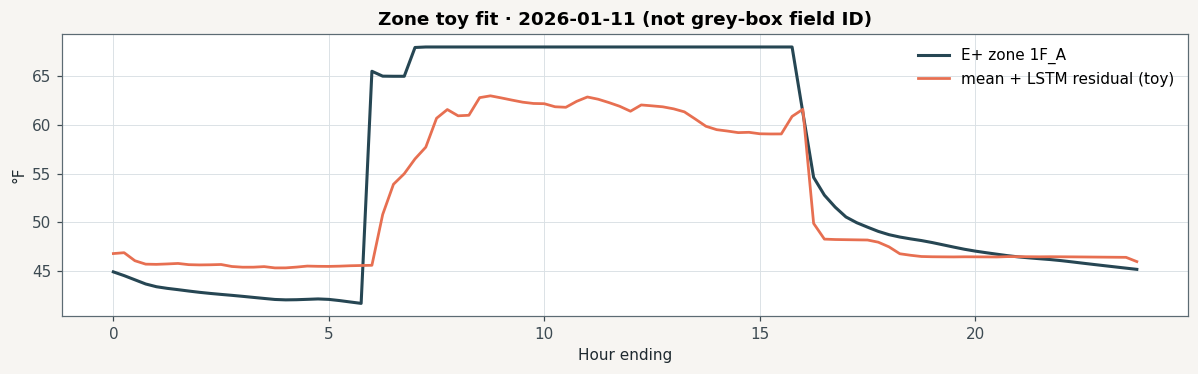

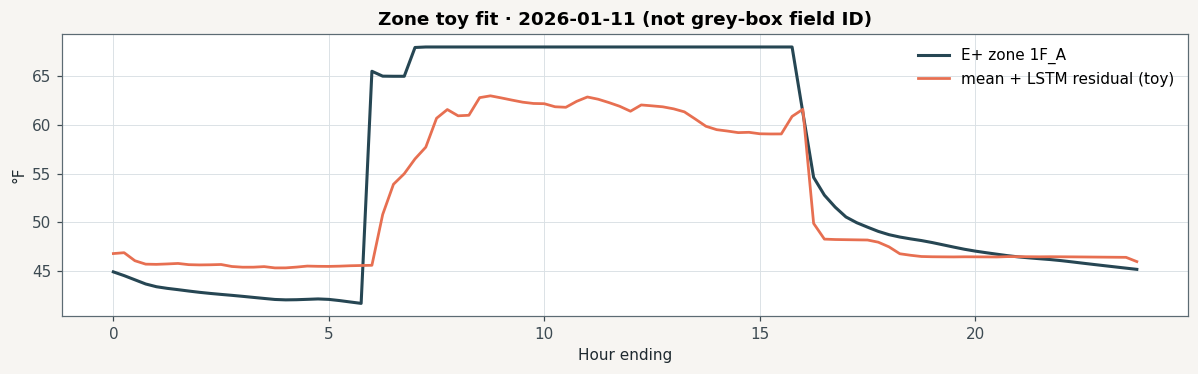

wrote C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\reports\figures\phys_lstm_fun\phys_lstm_fun_card.json


In [24]:
j = len(days[n_train:]) - 1
day = days[n_train + j]
z_true = Zones[n_train + j]
z_hat = z_true.mean() + pred_te[j, :, 1]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(hours, z_true, color="#264653", lw=2, label="E+ zone 1F_A")
ax.plot(hours, z_hat, color="#e76f51", lw=1.8, label="mean + LSTM residual (toy)")
ax.set_xlabel("Hour ending"); ax.set_ylabel("°F")
ax.set_title(f"Zone toy fit · {day} (not grey-box field ID)")
ax.legend(frameon=False)
fig.tight_layout()
save_fig(FIG / f"phys_lstm_zone_{day}.png", fig)
plt.show()

card = {
    "honesty": "FUN_EXPERIMENT",
    "promote": "NON_PROMOTABLE",
    "physics_family": "STRUCTURAL_LOAD_DIAGNOSTIC",
    "model": "PhysicsResidualLSTM",
    "a_phys": a_phys,
    "b_phys": b_phys,
    "epochs": EPOCHS,
    "train_days": days[:n_train],
    "test_days": days[n_train:],
    "score": score.to_dict(orient="records"),
    "note": "Toy physics+LSTM on IdealLoads E+ farm — not W2A, not field BACnet, not ship.",
}
(FIG / "phys_lstm_fun_card.json").write_text(json.dumps(card, indent=2), encoding="utf-8")
print("wrote", FIG / "phys_lstm_fun_card.json")